# 10 — Validate Against DFT Reference Data

Validates ML predictions against DFT calculations for selected configurations on and near the convex hull.

## Prerequisites / Input files
- `Fe-Mo/FullyCuratedParsedBriefSummary.pkl`
- `Fe-Mo/data/Validation/` — DFT validation data (included in repo)
- `Fe-Mo/results/voting_regressor_*.pkl` — ensemble models

## Outputs
- Validation metrics and figures in `Fe-Mo/graphs/`



In [1]:
from Tools.DatasetTools.DatasetOperator import Dataset
from dependencies.bopfoxfeaturizer.BopFoxFeaturizer.brief_summary_parser import StructSummaryParser
from Tools.DatasetTools import EVCurvesTools as EVtools
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

/home/mariano/.local/micromamba/envs/Test_MLFeMoTCPs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
plt.rc('text', usetex=False)

In [3]:
from importlib.machinery import SourceFileLoader

In [4]:
validation_dataset = 'Fe-Mo/validation_data/'

In [5]:
CollectedBSFile = os.path.join(validation_dataset, 'CollectedValidationBS.json')
if not os.path.exists(CollectedBSFile):
    try:
        fullvalidationBS = StructSummaryParser(dataset=validation_dataset,ForceMakeBS=True).BriefSummary
        fullvalidationBS.to_json(CollectedBSFile)
    except FileNotFoundError as E:
        raise FileNotFoundError("Probably need raw data!")
else:
    fullvalidationBS = pd.read_json(CollectedBSFile)


In [6]:
fullvalidationBS

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Fe_pv8Mo_sv22.sigma-BBABB.FM,bulk sigma-BBABB.FM,14.954763 A,-10.004507,224.285410 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,224.285410,14.954763,Fe_pv,Mo_sv,8,22,30
Fe_pv10Mo_sv20.sigma-ABBAB.FM,bulk sigma-ABBAB.FM,14.130625 A,-10.006896,237.907324 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,237.907324,14.130625,Fe_pv,Mo_sv,10,20,30
Fe_pv4Mo_sv20.C36-ABBBB.FM,bulk C36-ABBBB.FM,16.270923 A,-10.007837,204.470374 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,204.470374,16.270923,Fe_pv,Mo_sv,4,20,24
Fe_pv3Mo_sv10.mu-ABBBA.FM,bulk mu-ABBBA.FM,15.378254 A,-10.008565,402.123952 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,402.123952,15.378254,Fe_pv,Mo_sv,3,10,13
Fe_pv5Mo_sv24.chi-AABB.FM,bulk chi-AABB.FM,15.751001 A,-10.015010,216.183583 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,216.183583,15.751001,Fe_pv,Mo_sv,5,24,29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv3Mo_sv10.mu-ABBBA.NM,bulk mu-ABBBA,15.125643 A,-9.973264,240.020984 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,240.020984,15.125643,Fe_pv,Mo_sv,3,10,13
Fe_pv8Mo_sv22.sigma-BBABB.NM,bulk sigma-BBABB,14.698886 A,-9.976143,247.238692 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,247.238692,14.698886,Fe_pv,Mo_sv,8,22,30
Fe_pv1Mo_sv3.L12-AB3.FM,bulk L12-AB3.FM,14.806728 A,-9.986411,223.435464 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,223.435464,14.806728,Fe_pv,Mo_sv,1,3,4
Fe_pv8Mo_sv22.sigma-BBBBA.FM,bulk sigma-BBBBA.FM,15.095159 A,-9.991080,207.683558 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,207.683558,15.095159,Fe_pv,Mo_sv,8,22,30


In [7]:
remove_phases_query='Phase != "bcc" and Phase != "fcc" and Phase !="hcp"',

There is overlap betwee validation ds and training ds

In [8]:
BS = pd.read_json('Fe-Mo/FullyCuratedParsedBriefSummary.json')

In [9]:
validation_samples = fullvalidationBS.index.difference(BS.index)

In [10]:
validation_samples = validation_samples[~validation_samples.str.contains('.FM|sigma')]

In [11]:
len(validation_samples)

55

In [12]:
validationBS = fullvalidationBS.loc[validation_samples]

In [13]:
validationBS = validationBS[~validationBS.index.str.contains('sigma.[DU]')]

In [14]:
validationBS.to_json(os.path.join(validation_dataset, 'CuratedValidationBS_01.json'))

## Check EVcurves

The way to check if DFT calculations worked correctly is to check the existence of energy volume curves, and that the fit to an EOS equation is reasonable. 

In [15]:
from Tools.DatasetTools import EVCurvesTools as EVtools

In [16]:
fittedcurvesloc = os.path.join(validation_dataset, 'evcurvesfitted.json')
evcurvesloc = os.path.join(validation_dataset,'evcurves.json' )
goodnessloc = os.path.join(validation_dataset, 'goodness.json')
force = False

In [17]:
#EVtools = SourceFileLoader('EVtools', 'Tools/DatasetTools/EVCurvesTools.py').load_module()

In [18]:
test_indexes = validationBS.index[validationBS.index.str.contains('Mo_sv.*P.NM')]

In [19]:
validationBS.loc[test_indexes]

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms
Mo_sv56.P.NM,bulk P,16.233090 A,-10.689768,243.233916 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,1,243.233916,16.23309,Mo_sv,,56,0,56


In [20]:
#import subprocess
#from pathlib import Path
#
#mount_root = Path(validation_dataset).resolve()
#target_dirs = ["Fe_pv", "Fe_pv-Mo_sv", "Mo_sv"]
#target_paths = [(mount_root / directory).resolve() for directory in target_dirs]
#
#def _read_mounts():
#    mounts = {}
#    with open("/proc/mounts", "r", encoding="utf-8") as mount_file:
#        for line in mount_file:
#            parts = line.split()
#            if len(parts) >= 3:
#                mount_point = parts[1].replace("\\040", " ")
#                fs_type = parts[2]
#                mounts[mount_point] = fs_type
#    return mounts
#
#mounts = _read_mounts()
#missing_fuse_mounts = [
#    path for path in target_paths
#    if mounts.get(str(path), "").startswith("fuse") is False
#]
#
#if missing_fuse_mounts:
#    script_path = mount_root / "mount_data.sh"
#    if not script_path.exists():
#        raise FileNotFoundError(f"Missing mount script: {script_path}")
#    print("Missing FUSE mounts detected. Running mount_data.sh...")
#    subprocess.run(["bash", script_path.name], cwd=str(mount_root), check=True)
#else:
#    print("All target directories are already mounted with FUSE. Skipping mount_data.sh.")

In [21]:
pd.read_json(fittedcurvesloc, typ='series')

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurv

In [22]:
fittedcurvesloc

'Fe-Mo/validation_data/evcurvesfitted.json'

In [23]:
if not os.path.exists(fittedcurvesloc) or force:
    if not os.path.exists(evcurvesloc) or force:
        EV = EVtools.Evcurves(Indexes = validationBS.index, atoms=['Fe','Mo'], dataset = validation_dataset)#, search_str='**/volume_relaxed/**/volume-energy.dat')
        EV.load_evcurves( deltaks = validationBS['deltak'].astype(str), encuts = validationBS['encut'].astype(str))
        EVcurves = EV.evcurves
        EVcurves.to_json(evcurvesloc, indent = True)
    else:
        EVcurves = pd.read_json(evcurvesloc, typ='series')
    goodness, fitresults, r2  = EVtools.get_goodness(EVcurves, r2tol = 1e-3)
    if goodness.map(lambda g: False in g.values()).all():
        goodness = EVtools.invert_goodness(goodness)
    Goodness = pd.Series(goodness)
    Fits = pd.Series(fitresults)
    R2 = pd.Series(r2)
    for index, data in EVcurves.items():
        for key, evcurve in data.items():
            if index in R2.keys():
                if key in R2[index].keys():
                    data[key].update({'r2': R2[index][key], 'fit': Fits[index][key], 'IsGood': Goodness[index][key]})
    EVcurves.to_json(fittedcurvesloc, indent = True)
else:
    EVcurves = pd.read_json(fittedcurvesloc, typ='series')

# Rebuild dictionaries from the fitted curves content in a shared step.
r2 = {}
goodness = {}
fitresults = {}
for index, data in EVcurves.items():
    r2[index] = {}
    goodness[index] = {}
    fitresults[index] = {}
    for key, evcurve in data.items():
        r2[index][key] = evcurve.get('r2')
        goodness[index][key] = evcurve.get('IsGood')
        fitresults[index][key] = evcurve.get('fit')

R2 = pd.Series(r2)
Goodness = pd.Series(goodness)
Fits = pd.Series(fitresults)

In [24]:
EVcurves

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurv

## Recover Predicted values

In [25]:
validationBS.loc[test_indexes]['E0']

Mo_sv56.P.NM   -10.689768
Name: E0, dtype: float64

In [26]:
for index, param_curve in EVcurves[test_indexes].items():
    break
for params, curve in param_curve.items():
    break

In [27]:
EVcurves

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM    {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           {'xc=PBE-PAW.E=450.dk=0.020': {'evcurve': {'V'...
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          {'xc=PBE-PAW.E=450.dk=0.020': {'evcurv

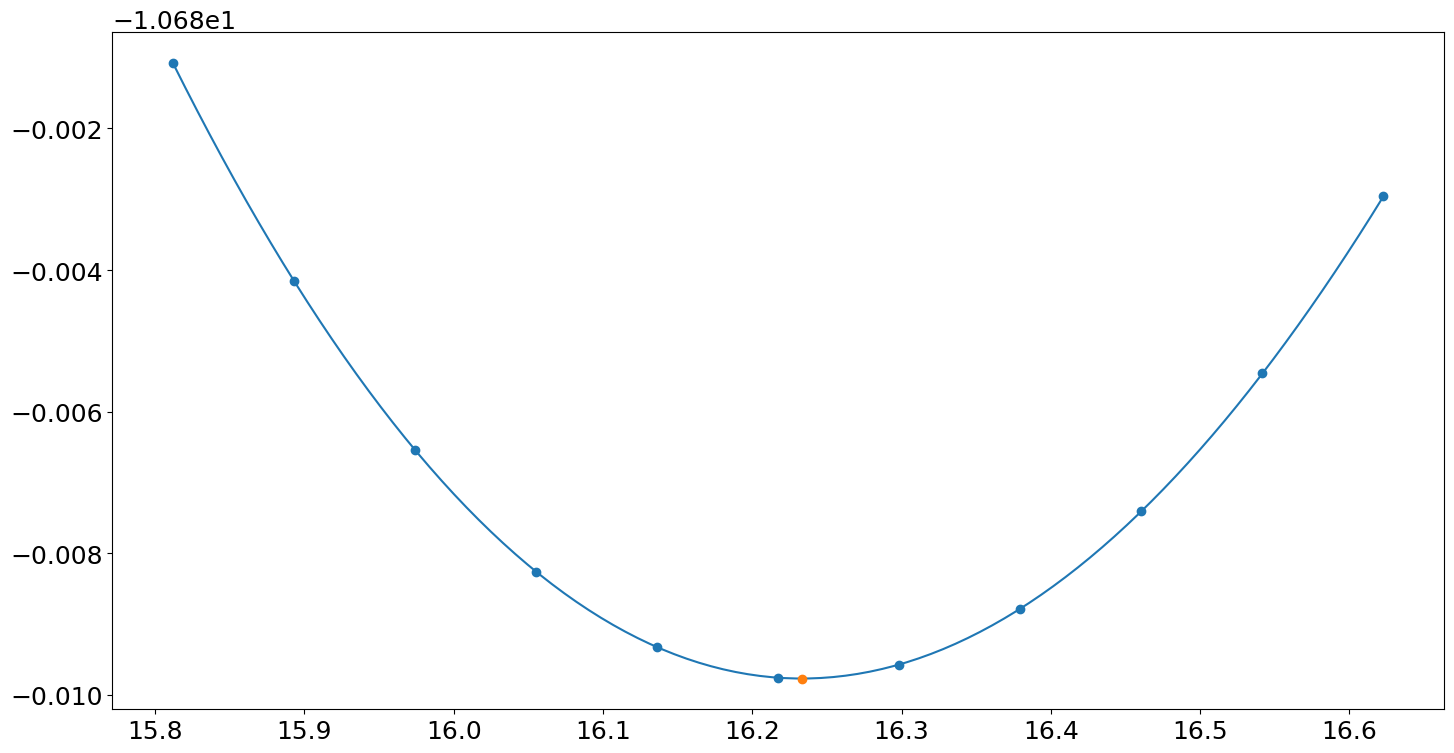

In [28]:
fig, ax = plt.subplots()
EVtools.plot_fitted_curve(curve['evcurve'], Fits[index][params], R2[index][params], ax = ax, fig=fig)
ax.plot([validationBS.loc[index]['V0']], [validationBS.loc[index]['E0']],'o')

In [29]:
EVcurves_df = pd.DataFrame.from_dict(EVcurves.to_dict(), orient='index')

In [30]:
empty_curves = EVcurves[EVcurves.map(lambda c: len(c)==0)].index

In [31]:
EVcurves[empty_curves]

Fe_pv5Mo_sv8.mu-ABBAA.NM    {}
dtype: object

In [32]:
complete_curves = EVcurves.index.difference(empty_curves)

Only take the validationBS with given EV curves

In [33]:
validationBS = validationBS.loc[complete_curves]
EVcurves = EVcurves[complete_curves]
R2 = R2[complete_curves]
Fits = Fits[complete_curves]

In [34]:
len(validationBS)

54

In [35]:
len(EVcurves)

54

## Get dataframes and remove failed e-v curves

Some energy-volume curves might have failed, goodness == False !, although it depends on the rtol parameter in the ev-curve parsing procedure. 

In [36]:
R2_df = pd.DataFrame.from_dict(R2.to_dict(), orient='index')
Fits_df = pd.DataFrame.from_dict(Fits.to_dict(), orient='index')
Better_evcurves = {}
for index, evcurves in EVcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_evcurves[index] = nonan_evcurves[nonan_evcurves.index][0]
Better_evcurves_df = pd.DataFrame.from_dict(Better_evcurves, orient='index')


In [37]:

ev_fit_results_df = pd.DataFrame.from_dict(Better_evcurves_df.ev_fit_results.to_dict(), orient='index')
fit_results = Better_evcurves_df.fit.map( lambda f : {name: val for name, val in zip(['E_murn', 'B_murn', 'Bdev_murn', 'V_murn'], f)})
fit_results_df = pd.DataFrame.from_dict(fit_results.to_dict(), orient='index')

In [38]:
fit_results_df

,E_murn,B_murn,Bdev_murn,V_murn
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM,-10.155736,252.712257,4.294026,14.799758
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM,-9.952566,236.434324,4.197154,15.127056
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM,-10.243163,255.169890,3.080850,14.805503
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,-10.107377,253.054832,4.323071,14.682012
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM,-10.077997,259.639741,4.509614,14.345506
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM,-10.078913,259.385684,4.213728,14.352911
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM,-9.605003,234.582400,4.235368,14.604673
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM,-9.888909,262.836641,4.612689,13.911231
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,-9.818704,263.971468,4.437112,13.775498
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM,-9.839677,263.933095,4.333948,13.788411


Text(0.5, 1.0, '54 Good Samples')

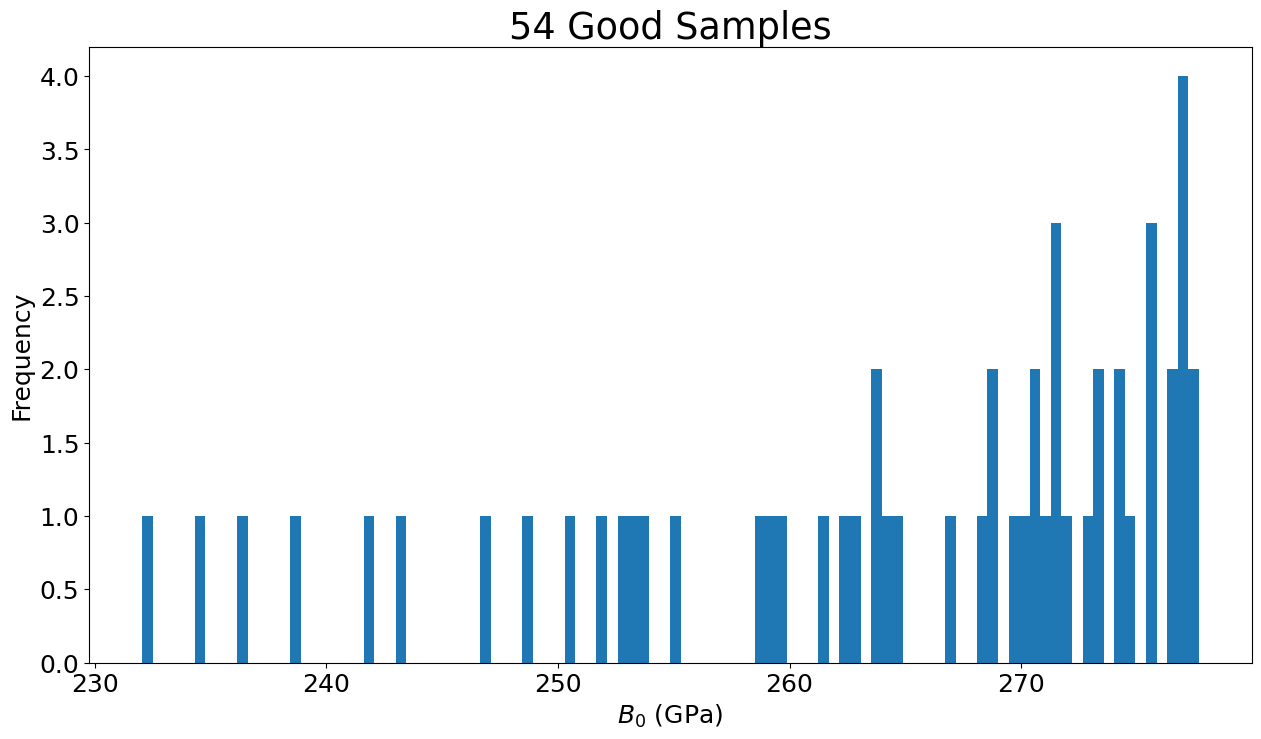

In [39]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [40]:
Better_evcurves_df.shape

(54, 6)

In [41]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [42]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [43]:
indexofbadsamples

Index([], dtype='object')

In [44]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

Text(0.5, 1.0, '54 Good Samples')

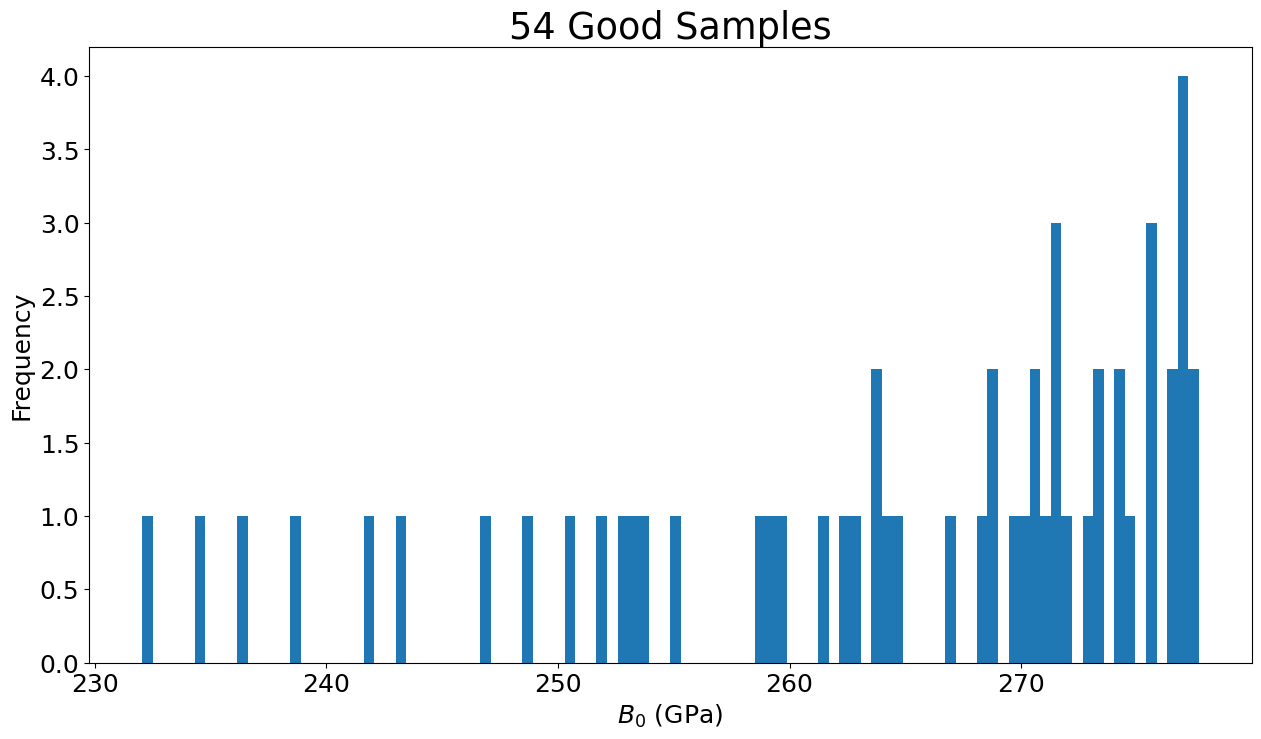

In [45]:
ax = fit_results_df[Better_evcurves_df.IsGood]['B_murn'].plot.hist(bins=100)
ax.set_xlabel(xlabel=r'$B_0$ (GPa)')
Ngood = Better_evcurves_df.IsGood.sum()
ax.set_title(f'{Ngood} Good Samples')

In [46]:
indexofgoodsamples = Better_evcurves_df.index[Better_evcurves_df.IsGood]

In [47]:
indexofbadsamples = Better_evcurves_df.index.difference(indexofgoodsamples) #[~Better_evcurves_df.IsGood]

In [48]:
Better_evcurves_df.index.difference(validationBS.index)

Index([], dtype='object')

/tmp/ipykernel_70583/816183106.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(title=f'{NGOOD} good samples')


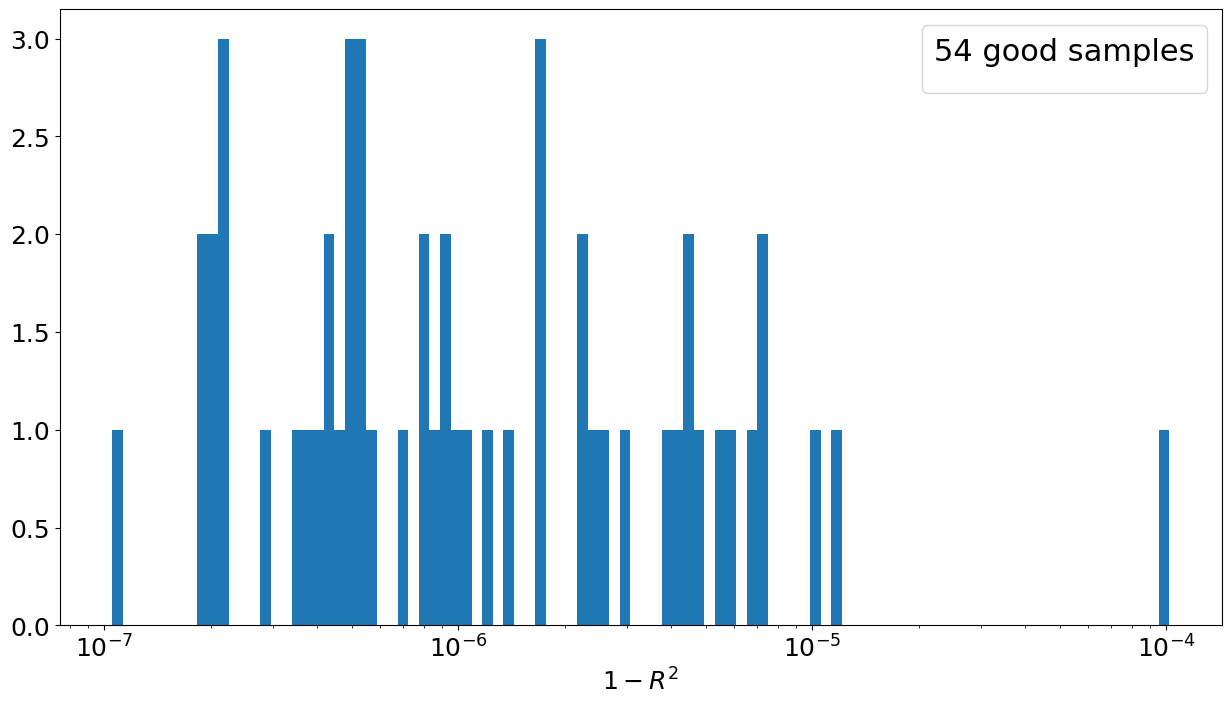

In [49]:
hist, bins = np.histogram(1-Better_evcurves_df.r2[indexofgoodsamples], bins=100)
logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
fig, ax = plt.subplots()
ax.hist(1-Better_evcurves_df.r2[indexofgoodsamples], bins=logbins)
Better_evcurves_df.r2[indexofgoodsamples]
ax.set_xscale('log')
xlabel = ax.set_xlabel('$1-R^2$')
NGOOD = len(indexofgoodsamples)
ax.legend(title=f'{NGOOD} good samples')

## Differences between fits and available data for bad samples

In [50]:
if len(indexofbadsamples) > 0:
    diff_fit_to_dataset = ((validationBS.B0[indexofbadsamples] - fit_results_df.B_murn[indexofbadsamples])/fit_results_df.B_murn[indexofbadsamples]).abs().to_frame().rename(columns={0: 'B0'})
    diff_fit_to_dataset['E0'] = ((validationBS.E0[indexofbadsamples] - fit_results_df.E_murn[indexofbadsamples])/fit_results_df.E_murn[indexofbadsamples]).abs().dropna()
    diff_fit_to_dataset['V0'] = ((validationBS.V0[indexofbadsamples] - fit_results_df.V_murn[indexofbadsamples])/fit_results_df.V_murn[indexofbadsamples]).abs().dropna()
    large_diff_E0 = diff_fit_to_dataset.query('E0 > 1e-5').index
    fig, ax = plt.subplots()
    hist, bins = np.histogram(diff_fit_to_dataset.E0, bins=100)
    logbins = np.logspace(np.log10(bins[0]), np.log10(bins[-1]), len(bins))
    loghist = plt.hist(diff_fit_to_dataset.E0, bins=logbins)
    fig = plt.xscale('log')
    fig = plt.yscale('log')
    for index in large_diff_E0:
        x = diff_fit_to_dataset.E0[index]
        y = 1
        ax.annotate(index, (x, y), rotation='90')
    plt.xlabel(r'$|(E_0 ^{fit} - E_0 ^{BS})/E_0^{BS}|$')

## Try to correct the bad fits by removing points 

In [51]:
len(indexofbadsamples)

0

In [52]:
GoodBS = validationBS.loc[indexofgoodsamples]

In [53]:
from importlib.machinery import SourceFileLoader
find_the_good_curve_inside = SourceFileLoader('find_the_good_curve_inside','Tools/DatasetTools/EVCurvesTools.py').load_module().find_the_good_curve_inside
is_common_sense_evcurve = SourceFileLoader('is_common_sense_evcurve','Tools/DatasetTools/EVCurvesTools.py').load_module().is_common_sense_evcurve
ev_per_angstrom3_to_GPA = 160.21

doexit = False

fixedevcurves = pd.Series([], name='FixedEVcurves')
fixedr2 = pd.Series([], name='FixedR2')
fixedfit = pd.Series([], name='Fixedfit')
tol = 1e-6
now_is_good = []
common_sense_evcurve = []
progress = tqdm(EVcurves[indexofbadsamples].items(), total = len(indexofbadsamples))
for index, paramcurve in progress:
    if index in fixedevcurves.keys():
        continue
    progress.set_description('index')
    if index in GoodBS.index:
        continue
    for paramspec, curvedata in paramcurve.items():
        r2, params_onreduced, reducedv, reducede = find_the_good_curve_inside(curvedata, tol=tol, reset_guess_params = True)
        common_sense_evcurve.append( is_common_sense_evcurve(reducedv, reducede, params_onreduced, unitsofb0='GPa'))
        now_is_good.append( (r2>1-tol) & common_sense_evcurve )
        now_is_good.append( (r2>1-tol) & common_sense_evcurve[-1] )
        progress.set_postfix_str(f'{index}, 1-r2 = {1-r2:.2e}, B0={params_onreduced[1]}, now is good = {now_is_good[-1]}')
        if params_onreduced[1] < 0 and now_is_good:
            raise ValueError('B0 is negative on '+index)
        fixedevcurves[index] = {
            paramspec: {
                'evcurve' :{ 'V' : reducedv , 'E': reducede },
                'ev_fit_results' :  {'E_murn': params_onreduced[0], 'V_murn' : params_onreduced[-1], 'B_murn': params_onreduced[1], 'Bdev_murn' : params_onreduced[2]},
                'r2' : r2,
                'IsGood' : now_is_good[-1],
                'fit': params_onreduced,
                'calc_param' : paramspec
            }
        }

0it [00:00, ?it/s]


In [54]:
fixedevcurves

Series([], Name: FixedEVcurves, dtype: object)

In [55]:
fixedevcurves_df = pd.DataFrame.from_dict(fixedevcurves.to_dict(), orient='index')

In [56]:
fixedevcurves_df.shape

(0, 0)

In [57]:
Better_fixedevcurves = {}

In [58]:
for index, evcurves in fixedevcurves_df.iterrows():
    nonan_evcurves = evcurves.dropna()
    if len(nonan_evcurves) > 1:
        break
    nonan_evcurves[nonan_evcurves.index][0]['calc_param'] = nonan_evcurves.index[0]
    Better_fixedevcurves[index] = nonan_evcurves[nonan_evcurves.index][0]

In [59]:
Better_fixedevcurves_df = pd.DataFrame.from_dict(Better_fixedevcurves, orient='index')

In [60]:
fixedR2 = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedR2[index] = {paramspec: curvedata['r2']}

In [61]:
fixedFits = pd.Series([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixedFits[index] = {paramspec: curvedata['fit']}

In [62]:
fixed_ev_fit_results = {} #pd.DataFrame([])
for index, curve in fixedevcurves.items():
    for paramspec, curvedata in curve.items():
        fixed_ev_fit_results[index] = pd.Series(curvedata['ev_fit_results'])
fixed_ev_fit_results_df = pd.DataFrame.from_dict(fixed_ev_fit_results, orient='index')

In [63]:
if len(Better_fixedevcurves_df)>0:
    indexoffixedgoodsamples = Better_fixedevcurves_df.query('IsGood == True').index

In [64]:
if 'indexoffixedgoodsmaples' in globals():
    indexoffixedbadsamples = Better_fixedevcurves_df.index.difference(indexoffixedgoodsamples)
    len(indexoffixedgoodsamples) + len(indexofgoodsamples)#+len(indexoffixedbadsamples)
    finalindexofsamples = indexofgoodsamples.append(indexoffixedgoodsamples)
    fixedValidationBS = validationBS.loc[finalindexofsamples]
else: 
    fixedValidationBS = validationBS
    fixed_ev_fit_results_df = fit_results_df
    

## Fixed quantities

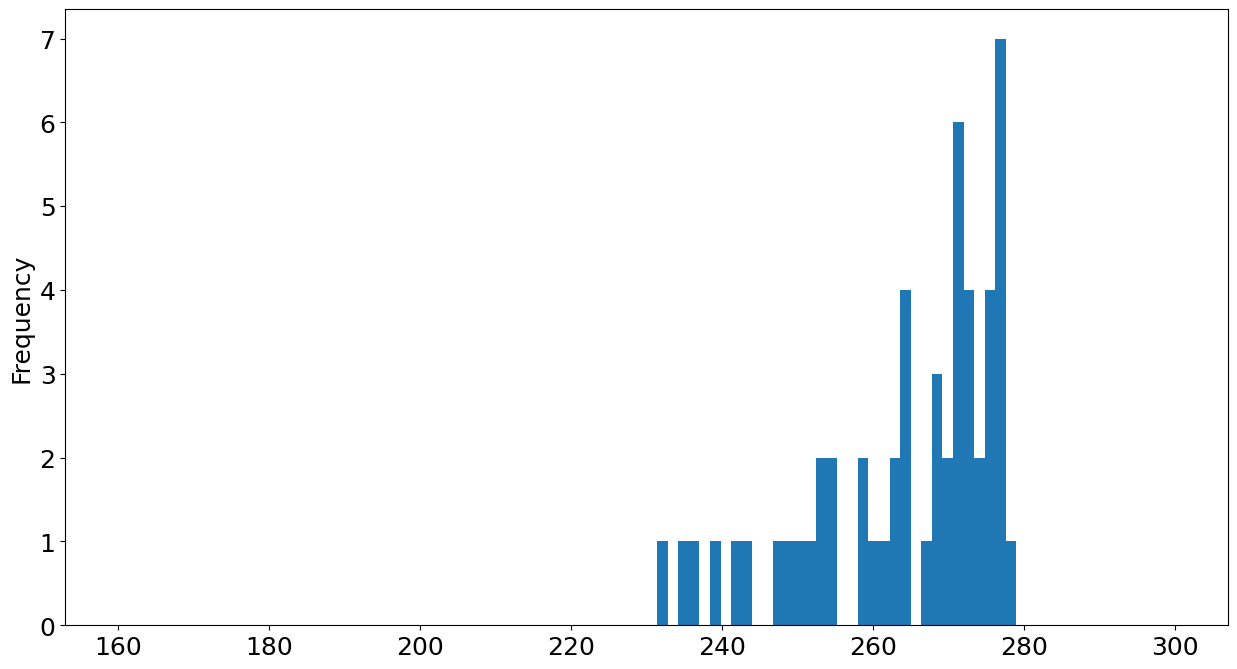

In [65]:
thebins = np.linspace(160, 300, 101)
ax = ev_fit_results_df.B_murn[indexofgoodsamples].plot.hist(bins=thebins)
if 'indexoffixedgoodsamples' in globals():
    fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
    fixed_ev_fit_results_df.B_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
    ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

In [66]:
if 'indexoffixedgoodsamples' in globals(): 
    thebins = np.linspace(-11, -9, 101)
    ax = ev_fit_results_df.E_murn[indexofgoodsamples].plot.hist(bins=thebins)
    fixed_ev_fit_results_df.E_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax = ax, alpha=0.5, )
    fixed_ev_fit_results_df.E_murn[indexoffixedgoodsamples].plot.hist(bins=thebins, ax=ax)
    ax.legend([f'{len(indexoffixedgoodsamples)} fixed good samples', f'{len(indexofgoodsamples)} good samples', f'{len(indexoffixedbadsamples)} fixed bad samples'])

## redefine the new good BS

but now I need to correct the E0, B0 and V0 to the results of the fix !

In [67]:
fixedValidationBS['E0'].dropna()

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM          -10.155735
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           -9.952566
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM         -10.243163
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM          -10.107377
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM         -10.077997
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM   -10.078913
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           -9.605003
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           -9.888909
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           -9.818704
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           -9.839677
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          -9.926956
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM           -9.673818
Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM          -9.758705
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    -9.709519
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM           -9.492255
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM          -9.536149
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    -9.349096
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM           -9.267082
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM           -9.291793
Fe_pv32Mo_sv

In [68]:
if 'indexoffixedbadsamples' in globals():
    fixedValidationBS.loc[indexoffixedgoodsamples,'E0'] = fixed_ev_fit_results_df['E_murn'][indexoffixedgoodsamples]
    fixedValidationBS.loc[indexoffixedgoodsamples,'V0'] = fixed_ev_fit_results_df['V_murn'][indexoffixedgoodsamples]
    fixedValidationBS.loc[indexoffixedgoodsamples,'B0'] = fixed_ev_fit_results_df['B_murn'][indexoffixedgoodsamples]
    fixedValidationBS.dropna().describe()

In [69]:
fixedValidationBS.shape

(54, 17)

In [70]:
fixedValidationBS['E0']

Fe_pv12Mo_sv41.R-BBABBABBBBB.NM          -10.155735
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM           -9.952566
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM         -10.243163
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM          -10.107377
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM         -10.077997
Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM   -10.078913
Fe_pv18Mo_sv35.R-BBBBBBAAABB.NM           -9.605003
Fe_pv19Mo_sv34.R-ABABAABBBBB.NM           -9.888909
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM           -9.818704
Fe_pv20Mo_sv33.R-BAAABABBBBB.NM           -9.839677
Fe_pv20Mo_sv36.P-BAABBBBABBAB.NM          -9.926956
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM           -9.673818
Fe_pv24Mo_sv32.P-AAABBBBABBAB.NM          -9.758705
Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM    -9.709519
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM           -9.492255
Fe_pv28Mo_sv28.P-AAABBBAABBAB.NM          -9.536149
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM    -9.349096
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM           -9.267082
Fe_pv32Mo_sv21.R-BAAAAAABBBB.NM           -9.291793
Fe_pv32Mo_sv

In [71]:
import re

In [72]:
def get_phase_from_index(theindex):
    phaseconfig = theindex.split('.')[1]
    phase = phaseconfig.split('-')[0]
    return phase

In [73]:
fixedValidationBS['Phase'] = fixedValidationBS.index.map(get_phase_from_index)

# New data for delta using alternative HT scheme

Unfortunately previous data was obtained an old high throughput scheme. Nowadays we have amstools to perform this task, and this was used with the same dft setup in order to get missing dft data

In [74]:
from ase import Atoms
import pandas as pd

In [75]:
import sys
import numpy.core as np_core
import numpy.core.numeric as np_numeric

# Compatibility shim for pickles written with NumPy internals under 'numpy._core'
sys.modules.setdefault('numpy._core', np_core)
sys.modules.setdefault('numpy._core.numeric', np_numeric)

validation_dataset_2 = 'Fe-Mo/inchulldft'
validation_data_file_2 = os.path.join(validation_dataset_2, 'BriefSummary.json')
if os.path.exists(validation_data_file_2):
    ValidationBS_extra = pd.read_json(validation_data_file_2)
else:
    raise FileNotFoundError('You may need DFT raw data')

In [76]:
def convert_lists_to_arrays(obj):
    """Recursively convert lists to numpy arrays in dictionaries"""
    if isinstance(obj, dict):
        return {k: convert_lists_to_arrays(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return np.array(obj)
    else:
        return obj

# Apply the conversion to the relax_optimized_structure column
atoms_dicts =  ValidationBS_extra['relax_optimized_structure'].map(convert_lists_to_arrays)

AtomsObjects = atoms_dicts.map(lambda d: Atoms.fromdict(d))

In [77]:
num_atoms_delta = pd.DataFrame.from_dict(AtomsObjects.map(lambda d: {s: n for s, n in d.symbols.formula.count().items()}).to_dict(), orient='index').fillna(0)

In [78]:
ValidationBS_extra = pd.concat([ValidationBS_extra, num_atoms_delta], axis=1)

In [79]:
def parse_name(thename):
    splittedname = thename.split('/')
    sample_id = splittedname[-3]
    sample_info = sample_id.split('.')
    return {'Mag': sample_info[-1], '' : sample_info[1], 'Phase' : sample_info[1].split('-')[0], 'sample_id': sample_id}

In [80]:
IDS = pd.DataFrame.from_dict(ValidationBS_extra.name.map(parse_name).to_dict(), orient='index')

In [81]:
ValidationBS_extra = pd.concat([IDS, ValidationBS_extra], axis=1)

In [82]:
ValidationBS_extra.set_index('sample_id', inplace=True)

In [83]:
ValidationBS_extra.columns

Index(['Mag', '', 'Phase', 'name', 'status', 'relax', 'murnaghan',
       'relax_optimized_structure', 'relax_energy', 'relax_forces',
       'relax_volume', 'relax_n_atom', 'relax_stress', 'murnaghan_volume',
       'murnaghan_energy', 'murnaghan_pressure',
       'murnaghan_equilibrium_energy', 'murnaghan_equilibrium_volume',
       'murnaghan_equilibrium_bulk_modulus', 'murnaghan_equilibrium_b_prime',
       'murnaghan_energy_rms', 'Fe', 'Mo'],
      dtype='object')

In [84]:
ValidationBS_extra.rename(columns={'murnaghan_equilibrium_bulk_modulus': 'B0', 'Fe': 'num_atom_A', 'Mo': 'num_atom_B', 'relax_n_atom': 'num_atoms'}, inplace=True)

In [85]:
ValidationBS_extra.columns

Index(['Mag', '', 'Phase', 'name', 'status', 'relax', 'murnaghan',
       'relax_optimized_structure', 'relax_energy', 'relax_forces',
       'relax_volume', 'num_atoms', 'relax_stress', 'murnaghan_volume',
       'murnaghan_energy', 'murnaghan_pressure',
       'murnaghan_equilibrium_energy', 'murnaghan_equilibrium_volume', 'B0',
       'murnaghan_equilibrium_b_prime', 'murnaghan_energy_rms', 'num_atom_A',
       'num_atom_B'],
      dtype='object')

In [86]:
ValidationBS_extra['E0'] = ValidationBS_extra['murnaghan_equilibrium_energy']/ValidationBS_extra['num_atoms']
ValidationBS_extra['V0'] = ValidationBS_extra['murnaghan_equilibrium_volume']/ValidationBS_extra['num_atoms']

In [87]:
ValidationBS_extra.head()['E0']

sample_id
Fe_pv56.delta-AAAAAAAAAAAAAA.NM          -8.012624
Fe_pv39Mo_sv14.R-AAAAAABAABB.NM          -8.903644
Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM    -8.468361
Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM   -9.908805
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM    -8.260014
Name: E0, dtype: float64

In [88]:
def get_n_atom(natoms):
    if natoms > 0:
        return 1
    return 0

In [89]:

#ValidationBS_delta['atom_A'] =
if 'atom_A' not in ValidationBS_extra.columns:
    ValidationBS_extra['atom_A'] = ValidationBS_extra['num_atom_A'].map(lambda a: get_n_atom(a)*'Fe_pv')
#ValidationBS_delta['atom_A'] =
if 'atom_B' not in ValidationBS_extra.columns:
    ValidationBS_extra['atom_B'] = ValidationBS_extra['num_atom_B'].map(lambda a: get_n_atom(a)*'Mo_sv')

In [90]:
fixedValidationBS.head()

,,V,E0,B,fit,xc,encut,deltak,ncrash,nelem,B0,V0,atom_A,atom_B,num_atom_A,num_atom_B,num_atoms,Phase
Fe_pv12Mo_sv41.R-BBABBABBBBB.NM,bulk R-BBABBABBBBB,14.799765 A,-10.155735,252.670511 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,252.670511,14.799765,Fe_pv,Mo_sv,12,41,53,R
Fe_pv12Mo_sv41.R-BBBBBBAABBB.NM,bulk R-BBBBBBAABBB,15.127063 A,-9.952566,236.397567 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,236.397567,15.127063,Fe_pv,Mo_sv,12,41,53,R
Fe_pv12Mo_sv44.P-BBABBBBBBBAB.NM,bulk P-BBABBBBBBBAB,14.805514 A,-10.243163,255.136017 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,255.136017,14.805514,Fe_pv,Mo_sv,12,44,56,P
Fe_pv13Mo_sv40.R-ABABBABBBBB.NM,bulk R-ABABBABBBBB,14.682019 A,-10.107377,253.012900 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,253.012900,14.682019,Fe_pv,Mo_sv,13,40,53,R
Fe_pv16Mo_sv40.P-BBABBBBABBAB.NM,bulk P-BBABBBBABBAB,14.345515 A,-10.077997,259.592633 GPa,murnaghan volume_relaxed,PBE-PAW,450,0.02,0,2,259.592633,14.345515,Fe_pv,Mo_sv,16,40,56,P


In [91]:
ValidationBS_extra.index

Index(['Fe_pv56.delta-AAAAAAAAAAAAAA.NM', 'Fe_pv39Mo_sv14.R-AAAAAABAABB.NM',
       'Fe_pv48Mo_sv8.delta-BBAAAAAAAAAAAA.NM',
       'Fe_pv20Mo_sv36.delta-BBBBBBBBAAABAA.NM',
       'Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM',
       'Fe_pv48Mo_sv8.delta-BABAAAAAAAAAAA.NM',
       'Fe_pv32Mo_sv24.delta-BBBAABBBAAAAAA.NM',
       'Fe_pv44Mo_sv12.delta-BBBAAAAAAAAAAA.NM',
       'Fe_pv16Mo_sv40.delta-BBBBBBBBABAAAB.NM',
       'Fe_pv44Mo_sv12.delta-AABBBAAAAAAAAA.NM',
       'Fe_pv28Mo_sv28.delta-BBBABBBBAAAAAA.NM',
       'Fe_pv28Mo_sv28.delta-BBBBBBBAAAAAAA.NM',
       'Fe_pv20Mo_sv36.delta-BBBBBBBBAAAAAB.NM',
       'Fe_pv16Mo_sv40.delta-BBBBBBBBABAABA.NM',
       'Fe_pv48Mo_sv8.delta-AABABAAAAAAAAA.NM',
       'Fe_pv36Mo_sv20.delta-BBBAABBAAAAAAA.NM',
       'Fe_pv24Mo_sv32.delta-BBBBBBBBAAAAAA.NM',
       'Fe_pv52Mo_sv4.delta-BAAAAAAAAAAAAA.NM',
       'Fe_pv24Mo_sv32.delta-BBBBBABBABAAAA.NM',
       'Fe_pv36Mo_sv20.delta-BBBBBAAAAAAAAA.NM',
       'Mo_sv56.delta-BBBBBBBBBBBBBB.NM'],
   

# Merge validation data

In [92]:
more_samples = fixedValidationBS.index.difference(ValidationBS_extra.index)

In [93]:
AllValidationBS = pd.concat([ValidationBS_extra, fixedValidationBS.loc[more_samples]], axis=0)

In [94]:
AllValidationBS.sort_values(by=['Phase'])

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,atom_A,atom_B,V,B,fit,xc,encut,deltak,ncrash,nelem
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,NaN,bulk M-ABBAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,13.775506 A,263.925712 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv40Mo_sv12.M-AAAAAAABABB.NM,NaN,bulk M-AAAAAAABABB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,11.615511 A,276.444886 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Mo_sv52.M.NM,NaN,bulk M,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Mo_sv,,16.380156 A,238.686723 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,1.0
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM,NaN,bulk M-AAAAAAABBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,11.990886 A,276.881627 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM,NaN,bulk M-BAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,13.239078 A,271.174559 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv36Mo_sv20.delta-BBBBBAAAAAAAAA.NM,NM,delta-BBBBBAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv36Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-511.414740,"[[0.00033969999999999996, 0.00121393, 0.001506...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Mo_sv56.delta-BBBBBBBBBBBBBB.NM,NM,delta-BBBBBBBBBBBBBB,delta,VASP_PBE_500_0.125_0.1_NM/Mo/delta/Mo_sv56.del...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-597.803112,"[[3.089e-05, 0.0017990200000000001, -0.0003198...",...,,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv28Mo_sv28.delta-AAAAAABBBBBABB.NM,NaN,bulk delta-AAAAAABBBBBABB,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,13.388972 A,253.884450 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv20Mo_sv36.delta-BBBBBBBBAAAAAB.NM,NM,delta-BBBBBBBBAAAAAB,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv20Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 42, 42, 42, 42, 4...",-554.836027,"[[-2.327e-05, -0.00127046, -0.0025501400000000...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [95]:
#fullvalidationBS['Mag'] = 
AllValidationBS['Mag'] = AllValidationBS.index.str.split('.').map(lambda i: i[-1])

In [96]:
AllValidationBS['Phase'] = AllValidationBS.index.str.split('.').map(lambda i: i[1].split('-')[0])


In [97]:
AllValidationBS.sort_values(by=['Phase', 'num_atom_A', 'Mag'])

,Mag,,Phase,name,status,relax,murnaghan,relax_optimized_structure,relax_energy,relax_forces,...,atom_A,atom_B,V,B,fit,xc,encut,deltak,ncrash,nelem
Fe_pv20Mo_sv32.M-ABBAABBBBBB.NM,NM,bulk M-ABBAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,13.775506 A,263.925712 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv24Mo_sv28.M-BAAAABBBBBB.NM,NM,bulk M-BAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,13.239078 A,271.174559 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv28Mo_sv24.M-AAAAABBBBBB.NM,NM,bulk M-AAAAABBBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,12.752561 A,276.932244 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv32Mo_sv20.M-AAAAAABBBBB.NM,NM,bulk M-AAAAAABBBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,12.352802 A,277.616677 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
Fe_pv36Mo_sv16.M-AAAAAAABBBB.NM,NM,bulk M-AAAAAAABBBB,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,Mo_sv,11.990886 A,276.881627 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Fe_pv52Mo_sv4.delta-AABAAAAAAAAAAA.NM,NM,delta-AABAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 4...",-462.560867,"[[-0.0008108400000000001, 0.00079078, -0.00207...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv52Mo_sv4.delta-BAAAAAAAAAAAAA.NM,NM,delta-BAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/FeMo/delta/Fe_pv52Mo...,finished,finished,finished,"{'numbers': [42, 42, 42, 42, 26, 26, 26, 26, 2...",-461.410542,"[[-7.071e-05, 0.00100854, -0.00095918], [-7.07...",...,Fe_pv,Mo_sv,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv56.delta-AAAAAAAAAAAAAA.NM,NM,delta-AAAAAAAAAAAAAA,delta,VASP_PBE_500_0.125_0.1_NM/Fe/delta/Fe_pv56.del...,finished,finished,finished,"{'numbers': [26, 26, 26, 26, 26, 26, 26, 26, 2...",-448.707000,"[[0.00134237, -0.0009403500000000001, -0.00018...",...,Fe_pv,,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Fe_pv56.delta.NM,NM,bulk delta,delta,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,Fe_pv,,10.461103 A,274.874823 GPa,murnaghan volume_relaxed,PBE-PAW,450.0,0.02,0.0,1.0


# Getting Formation Energies

In [98]:
from Tools.DatasetTools import ValidationSetNormalization as nv

In [99]:
ground_state_energies ={ ('Fe_pv','NM'): -8.18407186323532,
                       ('Mo_sv', 'NM'): -10.932821158319513,
                      }
# taken from ground_state_energies in notebook 03

In [100]:
normalizer = nv.briefsummary_normalizer(
    ground_states=ground_state_energies, init_bs=AllValidationBS, 
    atomA='Fe', atomB = 'Mo'
)

In [101]:
AllValidationBS['EF'] = normalizer.get_formation_energies()

In [102]:
AllValidationBS[[f'x_{normalizer.atomA}',f'x_{normalizer.atomB}' ]] = normalizer.get_atom_composition()

# saving to Json

In [103]:
AllValidationBS.to_json(os.path.join(validation_dataset, 'FullyCuratedParsedBriefSummary.json'), indent=True)